In [3]:
## ONLY NECESSARY IF RUNNING ON GOOGLE COLAB

# Install the gurobipy package
# !pip install gurobipy

# Specifying your individual Gurobi license
# params = {
# "WLSACCESSID": 'b2bfdc15-1ff1-5cc9-ac78-945146fe13ba',
# "WLSSECRET": 'c92828e2-cb7e-42d5-abac-8e185af24edb',
# "LICENSEID": 1234567,
# }

In [4]:
# import the gurobi packages and define the model
import gurobipy as gp      # all Gurobi functions and classes
from gurobipy import GRB   # contains solver parameters such as minimize/maximize
env = gp.Env()             # declare an environment: on Colab use gp.Env(params=params) 
mdl = gp.Model(env=env)    # declare the model

# import local data
# data_path = "/Users/mlwu/Documents/CMU/tepper_courses/Optimization for Perspective Analytics/quizzes/data/filename.csv"

Restricted license - for non-production use only - expires 2026-11-23


In [5]:
# Variables
x = mdl.addVar(lb=0, name="wheat")
y = mdl.addVar(lb=0, name="corn")

In [6]:
# Objective
mdl.setObjective(200*x + 300*y, GRB.MAXIMIZE)

In [7]:
# Constraints
mdl.addConstr(2*x + 4*y <= 120)   # fertilizer
mdl.addConstr(3*x + 2*y <= 100)   # labor
mdl.addConstr(x + y <= 60)        # land

<gurobi.Constr *Awaiting Model Update*>

In [8]:
mdl.optimize()

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Max
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 3 rows, 2 columns and 6 nonzeros
Model fingerprint: 0xebf24f00
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [2e+02, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 1e+02]
Presolve time: 0.00s
Presolved: 3 rows, 2 columns, 6 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.0000000e+32   4.750000e+30   5.000000e+02      0s
       3    1.0000000e+04   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.000000000e+04


In [9]:
print("Objective = ", mdl.ObjVal)

Objective =  10000.0


In [10]:
print("x = ", x)
print("y = ", y)

x =  <gurobi.Var wheat (value 20.0)>
y =  <gurobi.Var corn (value 20.0)>


In [11]:
mdl.printAttr('X')


    Variable            X 
-------------------------
       wheat           20 
        corn           20 


In [12]:
# Create model
mdl = gp.Model("Farmer_with_potatoes")

# Decision variables (acres)
x = mdl.addVar(lb=0, name="wheat")
y = mdl.addVar(lb=0, name="corn")
z = mdl.addVar(lb=0, name="potatoes")  # NEW

# Objective: maximize profit
mdl.setObjective(200 * x + 300 * y + 275 * z, GRB.MAXIMIZE)

# Constraints
mdl.addConstr(2 * x + 4 * y + 3 * z <= 120, "Fertilizer")
# mdl.addConstr(3 * x + 2 * y + 3 * z <= 100, "Labor")
mdl.addConstr(3 * x + 2 * y + 3 * z <= 150, "Labor")
mdl.addConstr(x + y + z <= 60, "Land")

# Optimize model
mdl.optimize()

# Output results
if mdl.status == GRB.OPTIMAL:
    print(f"Optimal solution:")
    print(f"  Wheat:    {x.X:.2f} acres")
    print(f"  Corn:     {y.X:.2f} acres")
    print(f"  Potatoes: {z.X:.2f} acres")
    print(f"Maximum Profit: ${mdl.ObjVal:.2f}")

Restricted license - for non-production use only - expires 2026-11-23
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Max
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 3 rows, 3 columns and 9 nonzeros
Model fingerprint: 0x84fadeec
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [2e+02, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 2e+02]
Presolve time: 0.00s
Presolved: 3 rows, 3 columns, 9 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.7500000e+32   7.250000e+30   7.750000e+02      0s
       4    1.1500000e+04   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.150000000e+04
Optimal solution:
  Wheat:    30.00 acres
  Corn:     0.00 acres
  Potatoes: 20.00 acres
Maximum Profit: $11500.00


# Optimization for Agricultural Planning
Farmer's Profit Maximization Model with Three Crops and Resource Constraints

In [ ]:
## Sensitivity Analysis & Shadow Prices
# “Only binding constraints with nonzero shadow prices limit the objective. Non-binding constraints have no impact.”
# — Hillier & Lieberman, 2005

# Print shadow prices (dual values) for constraints
print("\nShadow Prices (Dual Values):")
for c in mdl.getConstrs():
    print(f"Constraint '{c.ConstrName}': Shadow Price = {c.Pi:.2f}")

# Print reduced costs for decision variables
print("\nReduced Costs:")
for v in mdl.getVars():
    print(f"Variable '{v.VarName}': Reduced Cost = {v.RC:.2f}")


Shadow Prices (Dual Values):
Constraint 'Fertilizer': Shadow Price = 75.00
Constraint 'Labor': Shadow Price = 16.67
Constraint 'Land': Shadow Price = 0.00

Reduced Costs:
Variable 'wheat': Reduced Cost = 0.00
Variable 'corn': Reduced Cost = -33.33
Variable 'potatoes': Reduced Cost = 0.00


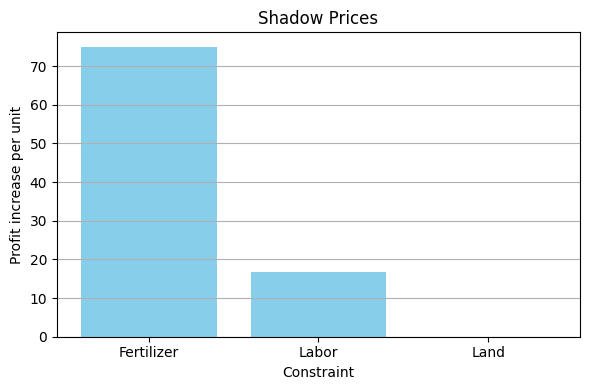

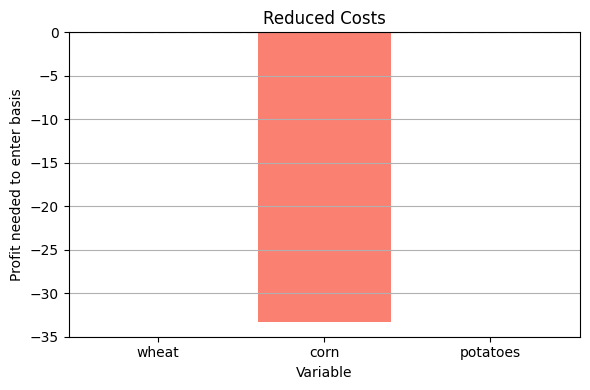

In [14]:
import matplotlib.pyplot as plt

# Shadow Prices Bar Plot
dual_names = [c.ConstrName for c in mdl.getConstrs()]
dual_values = [c.Pi for c in mdl.getConstrs()]

plt.figure(figsize=(6, 4))
plt.bar(dual_names, dual_values, color="skyblue")
plt.title("Shadow Prices")
plt.ylabel("Profit increase per unit")
plt.xlabel("Constraint")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Reduced Costs Bar Plot
rc_names = [v.VarName for v in mdl.getVars()]
rc_values = [v.RC for v in mdl.getVars()]

plt.figure(figsize=(6, 4))
plt.bar(rc_names, rc_values, color="salmon")
plt.title("Reduced Costs")
plt.ylabel("Profit needed to enter basis")
plt.xlabel("Variable")
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Use Colab for sliders
import ipywidgets as widgets
from IPython.display import display, clear_output

def simulate_corn_profit(new_profit):
    clear_output(wait=True)
    
    # Build new model
    m = gp.Model("What_if_corn")
    x = m.addVar(lb=0, name="wheat")
    y = m.addVar(lb=0, name="corn")
    z = m.addVar(lb=0, name="potatoes")
    
    m.setObjective(200 * x + new_profit * y + 275 * z, GRB.MAXIMIZE)
    m.addConstr(2 * x + 4 * y + 3 * z <= 120, "Fertilizer")
    m.addConstr(3 * x + 2 * y + 3 * z <= 150, "Labor")  # Using 150 labor case
    m.addConstr(x + y + z <= 60, "Land")
    
    m.optimize()
    
    print(f"\nCorn Profit: ${new_profit:.2f}/acre")
    print(f"Optimal Profit: ${m.ObjVal:.2f}")
    for v in m.getVars():
        print(f"{v.VarName.capitalize():<10}: {v.X:.2f} acres")
    
    # Optional: show reduced cost of corn
    corn_rc = [v for v in m.getVars() if v.VarName == "corn"][0].RC
    print(f"Reduced Cost of Corn: {corn_rc:.2f}")

# Create interactive slider
corn_slider = widgets.FloatSlider(
    value=300,
    min=200,
    max=400,
    step=5,
    description='Corn Profit:',
    continuous_update=False
)

display(corn_slider)
widgets.interact(simulate_corn_profit, new_profit=corn_slider)

FloatSlider(value=300.0, continuous_update=False, description='Corn Profit:', max=400.0, min=200.0, step=5.0)

interactive(children=(FloatSlider(value=300.0, continuous_update=False, description='Corn Profit:', max=400.0,…

<function __main__.simulate_corn_profit(new_profit)>

In [16]:
from IPython.display import display
import pandas as pd

# Collect shadow prices
shadow_data = {
    'Constraint': [c.ConstrName for c in mdl.getConstrs()],
    'Shadow Price ($)': [c.Pi for c in mdl.getConstrs()],
    'Binding?': [abs(c.Slack) < 1e-6 for c in mdl.getConstrs()]
}

df_shadow = pd.DataFrame(shadow_data)
display(df_shadow)

# Collect reduced costs
rc_data = {
    'Variable': [v.VarName for v in mdl.getVars()],
    'Reduced Cost': [v.RC for v in mdl.getVars()],
    'In Solution?': [v.X > 1e-6 for v in mdl.getVars()]
}

df_rc = pd.DataFrame(rc_data)
display(df_rc)

,Constraint,Shadow Price ($),Binding?
0,Fertilizer,75.000000,True
1,Labor,16.666667,True
2,Land,0.000000,False


,Variable,Reduced Cost,In Solution?
0,wheat,0.000000,True
1,corn,-33.333333,False
2,potatoes,0.000000,True


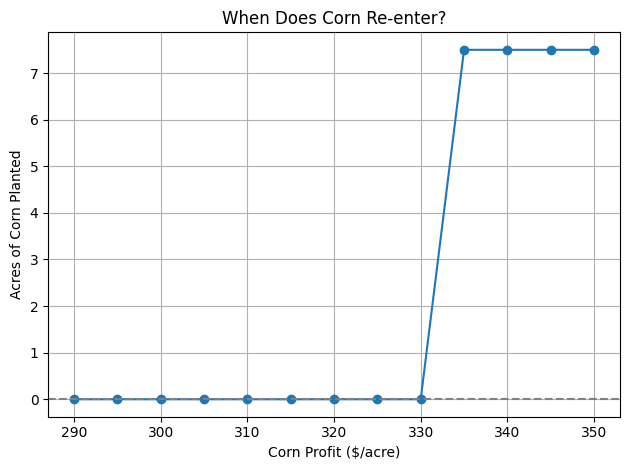

In [17]:
# Sensitivity analysis visual
profits = list(range(290, 351, 5))
corn_acres = []

for p in profits:
    m = gp.Model()
    x = m.addVar(lb=0)
    y = m.addVar(lb=0)
    z = m.addVar(lb=0)
    m.setObjective(200*x + p*y + 275*z, GRB.MAXIMIZE)
    m.addConstr(2*x + 4*y + 3*z <= 120)
    m.addConstr(3*x + 2*y + 3*z <= 150)
    m.addConstr(x + y + z <= 60)
    m.setParam('OutputFlag', 0)
    m.optimize()
    corn_acres.append(y.X)

plt.plot(profits, corn_acres, marker='o')
plt.title("When Does Corn Re-enter?")
plt.xlabel("Corn Profit ($/acre)")
plt.ylabel("Acres of Corn Planted")
plt.axhline(0, linestyle='--', color='gray')
plt.grid(True)
plt.tight_layout()
plt.show()

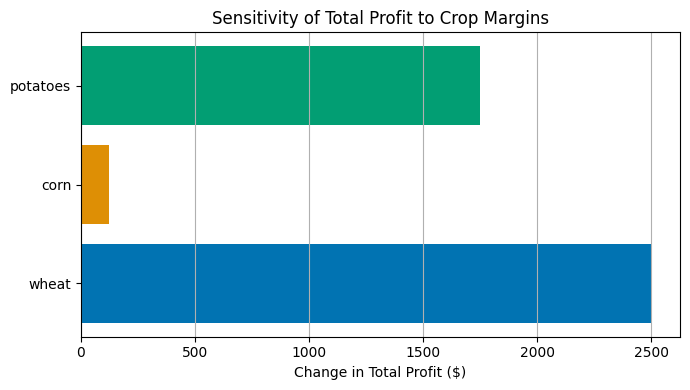

In [20]:
import seaborn as sns
palette = sns.color_palette("colorblind")
crop_names = ['wheat', 'corn', 'potatoes']

# Tornado plot
profit_changes = []

for idx, (crop, base, (low, high)) in enumerate(zip(crop_names, base_profits, ranges)):
    # LOW PROFIT
    low_model = gp.Model()
    x = low_model.addVar(lb=0)
    y = low_model.addVar(lb=0)
    z = low_model.addVar(lb=0)
    low_profits = base_profits.copy()
    low_profits[idx] = low
    low_model.setObjective(low_profits[0]*x + low_profits[1]*y + low_profits[2]*z, GRB.MAXIMIZE)
    for constr in [
        (2, 4, 3, 120),
        (3, 2, 3, 150),
        (1, 1, 1, 60)
    ]:
        low_model.addConstr(constr[0]*x + constr[1]*y + constr[2]*z <= constr[3])
    low_model.setParam('OutputFlag', 0)
    low_model.optimize()

    # HIGH PROFIT
    high_model = gp.Model()
    x2 = high_model.addVar(lb=0)
    y2 = high_model.addVar(lb=0)
    z2 = high_model.addVar(lb=0)
    high_profits = base_profits.copy()
    high_profits[idx] = high
    high_model.setObjective(high_profits[0]*x2 + high_profits[1]*y2 + high_profits[2]*z2, GRB.MAXIMIZE)
    for constr in [
        (2, 4, 3, 120),
        (3, 2, 3, 150),
        (1, 1, 1, 60)
    ]:
        high_model.addConstr(constr[0]*x2 + constr[1]*y2 + constr[2]*z2 <= constr[3])
    high_model.setParam('OutputFlag', 0)
    high_model.optimize()

    # Store profit delta
    profit_changes.append(high_model.ObjVal - low_model.ObjVal)

# Plot
plt.figure(figsize=(7, 4))
for i, (name, delta) in enumerate(zip(crop_names, profit_changes)):
    plt.barh(name, delta, color=palette[i % len(palette)])
plt.title("Sensitivity of Total Profit to Crop Margins")
plt.xlabel("Change in Total Profit ($)")
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

### Optimization Summary and Recommendation
We note that corn is excluded from the solution. Its reduced cost is -33.33, meaning it must become at least $333.33/acre in profit to re-enter the plan.

**Optimal Solution @ CP (Labor = 150 hours)**
- 30 acres of wheat
- 20 acres of potatoes
- 0 acres of corn

**Shadow Pricing**
- Fertilizer is the most valuable resource, with a marginal value of $75/ton.
- Labor provides moderate value at $16.67/hour.
- Land is not limiting under current conditions.

**Sensitivity Analysis**
- Total profit is most sensitive to changes in wheat and potato margins.
- Corn only becomes viable when its price exceeds $330/acre.
- Potatoes and wheat dominate due to their better resource-to-profit ratios under current constraints.

**Recommendation**
- Secure additional fertilizer if possible.
- Monitor corn prices; if the market improves, revisit planting strategy.
- Do not prioritize expanding land at this stage, as it is currently underutilized.